# 0. Page de garde

**Titre du projet :** IA de détection précoce du diabète à partir de données cliniques tabulaires  
**Candidat :** Said Kasmi  
**Date de remise :** 2026-03-27  
**Version du notebook :** v1.0  
**Environnement d’exécution :** Python 3.11, pandas, numpy, matplotlib, scikit-learn, joblib

---

Ce notebook constitue un livrable certifiant unique. Il sert à la fois de support technique, de preuve de compétence et de journal de bord argumenté.

# 1. Résumé exécutif

Le besoin métier traité dans ce projet est la détection précoce du diabète dans un contexte hospitalier. L’objectif est de proposer un **outil d’aide à la décision** capable d’identifier les patients à risque à partir de données cliniques anonymisées.

L’approche générale repose sur :
- l’analyse du dataset `medical_diabetes_dataset.csv`,
- la vérification de la qualité, de la disponibilité et de l’exploitabilité des données,
- la préparation du jeu de données,
- la comparaison de plusieurs modèles de classification supervisée,
- la formulation d’une stratégie d’industrialisation conforme aux contraintes d’un environnement médical.

Le dataset contient **800 lignes et 16 colonnes**. Une première analyse montre qu’il ne comporte ni valeurs manquantes ni doublons techniques, mais présente deux points de vigilance majeurs :
1. un **fort déséquilibre de classes** (`diabetes_risk=1` ≈ 94.9%) ;
2. une **fuite de cible** très probable via les colonnes `diabetes_type` et `diabetes_cause`, qui semblent refléter un diagnostic déjà établi.

Le principal résultat méthodologique de ce notebook est donc double :
- construire un pipeline exécutable de bout en bout ;
- démontrer qu’en santé, la performance brute ne suffit pas si le protocole de modélisation n’est pas réaliste cliniquement.

Les limites identifiées concernent la représentativité du dataset, l’absence de série temporelle, l’absence d’images réelles malgré la présence d’un score rétinien, et l’extrême déséquilibre de la cible.

# 2. Cadrage métier et cas d’usage

## 2.1 Contexte métier
Un hôpital universitaire souhaite disposer d’une solution d’IA pour détecter plus tôt les patients à risque de diabète, réduire les délais diagnostiques et renforcer la prévention.

## 2.2 Besoin à adresser
Le cas d’usage retenu est un problème de **classification binaire** : prédire `diabetes_risk` à partir de variables démographiques, biologiques, cliniques et comportementales.

## 2.3 Valeur attendue
- Orienter plus rapidement les patients vers un contrôle médical approfondi.
- Aider à la priorisation dans un contexte de charge hospitalière.
- Renforcer l’aide à la décision sans remplacer le médecin.

## 2.4 Hypothèses et contraintes
- Le modèle est utilisé en **aide à la décision**, jamais en diagnostic autonome.
- Les données sont anonymisées.
- Les variables postérieures au diagnostic ne doivent pas être utilisées dans un scénario réaliste.
- Le projet doit rester explicable, traçable et industrialisable.

## 2.5 Critères de réussite
- Notebook exécutable et compréhensible sans oral.
- Raisonnement technique documenté.
- Modèle cohérent avec le contexte métier.
- Indicateurs adaptés au risque clinique.
- Proposition d’architecture cible et de cadre MLOps.

## Journal de bord — cadrage
- Le besoin métier a été reformulé en problème de classification supervisée.
- Le cas d’usage a été volontairement restreint à la **partie tabulaire** car aucune image rétinienne native n’est fournie.
- Le projet est positionné comme une aide à la décision, ce qui limite le risque d’usage abusif.

# 3. Données : disponibilité, gouvernance et alternatives

## 3.1 Représentativité et adéquation aux besoins métiers
Le jeu de données fourni est globalement cohérent avec le cas d’usage. Il contient les variables a minima attendues pour étudier le risque de diabète : glycémie, HbA1c, IMC, antécédents familiaux, facteurs comportementaux et un score rétinien.

## 3.2 Existence, disponibilité et accès
- Source utilisée : `medical_diabetes_dataset.csv`
- Accès : local, direct, exploitable dans le notebook
- Type : données tabulaires anonymisées

## 3.3 Données pertinentes identifiées
- Variables biométriques : `age`, `bmi`
- Variables biologiques : `glucose_level`, `hba1c`, `cholesterol`, `triglycerides`
- Variables cliniques : `blood_pressure`, `retinopathy_score`
- Facteurs de risque : `family_history`, `physical_activity_level`, `smoker`
- Cible : `diabetes_risk`

## 3.4 Données à exclure ou à surveiller
- `patient_id` : identifiant technique, non prédictif
- `diabetes_type`, `diabetes_cause` : variables probablement post-diagnostic

## 3.5 Gouvernance et cycle de vie
Le cycle de vie des données doit inclure : collecte, contrôle qualité, transformation, usage analytique, versioning, archivage, auditabilité et documentation des traitements.

## 3.6 Solutions alternatives si indisponibilité des données
Si le dataset était incomplet ou inaccessible, plusieurs solutions pourraient être envisagées :
- recours à un jeu public médical comparable pour prototypage,
- enrichissement par données longitudinales hospitalières,
- ajout d’images rétiniennes réelles si le volet CNN doit être activé,
- simulation contrôlée pour tests techniques, en séparant clairement cela d’un usage clinique.

## Journal de bord — données
- Les besoins métiers et les cas d’usage ont été confrontés aux colonnes réellement disponibles.
- La disponibilité et l’accès aux données ont été vérifiés avant toute modélisation.
- Des alternatives ont été anticipées en cas d’absence de certaines sources.

# 4. Enjeux éthiques, sociétaux et conformité

## 4.1 Risques éthiques et sociétaux identifiés
L’IA en santé expose à des enjeux élevés : faux négatifs, biais de population, explicabilité, responsabilité médicale et protection des données.

## 4.2 Chartes et cadres de référence pris en compte
Le projet est pensé dans l’esprit :
- des principes européens de confiance dans l’IA,
- des exigences françaises et européennes en matière de protection des données,
- d’une gouvernance de l’IA responsable : transparence, supervision humaine, robustesse et traçabilité.

## 4.3 Biais et dilemmes éthiques
- **Biais de représentativité** : le dataset n’est pas nécessairement représentatif d’une population hospitalière réelle.
- **Déséquilibre de classes** : peut tromper l’interprétation des métriques.
- **Fuite de cible** : améliore artificiellement les performances mais rend le modèle invalide en pratique.
- **Dilemme** : accepter un modèle “très performant” mais non réaliste, ou un modèle plus honnête mais moins flatteur.

## 4.4 Mesures de réduction des risques
- Exclusion des variables fuyantes.
- Priorité donnée à l’interprétabilité.
- Maintien du médecin dans la boucle.
- Documentation des limites et des seuils d’usage.

## 4.5 Portage aux parties prenantes
Les risques doivent être explicitement communiqués au commanditaire, aux équipes conformité, juridiques, sécurité et métier avant tout passage en production.

## — éthique
- Les principaux risques éthiques ont été identifiés avant la phase de modélisation.
- Le choix a été fait de privilégier la validité clinique à la seule performance apparente.

In [2]:
# 5. Chargement et compréhension des données
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_PATH = Path('medical_diabetes_dataset.csv')
assert DATA_PATH.exists(), f'Fichier introuvable : {DATA_PATH.resolve()}'

# Le CSV fourni nécessite un encodage latin1.
df = pd.read_csv(DATA_PATH, encoding='latin1')
print('Shape:', df.shape)
display(df.head())

Shape: (800, 16)


,patient_id,age,gender,bmi,glucose_level,hba1c,blood_pressure,cholesterol,triglycerides,retinopathy_score,family_history,physical_activity_level,smoker,diabetes_risk,diabetes_type,diabetes_cause
0,1,22,F,22.48,245.9,7.46,126,133,84,0.343,1,élevé,1,1,mody,hereditary
1,2,72,M,38.52,95.1,11.82,120,180,282,0.235,1,moyen,1,1,type_2,lifestyle
2,3,60,Autre,30.07,235.7,6.64,155,214,91,0.998,0,moyen,1,1,type_2,lifestyle
3,4,35,M,30.67,83.2,10.81,94,231,303,0.764,1,élevé,1,1,type_2,lifestyle
4,5,52,M,24.99,233.6,9.68,123,124,212,0.226,0,moyen,0,1,lada,autoimmune


In [3]:
# Description des variables et premiers contrôles de cohérence
print('Types des colonnes :')
display(df.dtypes.to_frame('dtype'))

print('Valeurs manquantes :')
display(df.isna().sum().to_frame('missing_count'))

print('Nombre de doublons techniques :', df.duplicated().sum())

print('Distribution de la cible :')
display(df['diabetes_risk'].value_counts(dropna=False).rename_axis('class').to_frame('count'))

Types des colonnes :


,dtype
patient_id,int64
age,int64
gender,object
bmi,float64
glucose_level,float64
hba1c,float64
blood_pressure,int64
cholesterol,int64
triglycerides,int64
retinopathy_score,float64


Valeurs manquantes :


,missing_count
patient_id,0
age,0
gender,0
bmi,0
glucose_level,0
hba1c,0
blood_pressure,0
cholesterol,0
triglycerides,0
retinopathy_score,0


Nombre de doublons techniques : 0
Distribution de la cible :


,count
class,
1,759
0,41


## — chargement et compréhension

L’exécution du notebook confirme que le jeu de données contient **800 lignes et 16 colonnes**.  
Aucune valeur manquante n’a été détectée et aucun doublon exact n’a été identifié, ce qui constitue un point positif pour la suite de la modélisation.

La distribution de la cible révèle en revanche un **fort déséquilibre** :
- classe `1` : **759** observations
- classe `0` : **41** observations

Autrement dit, le dataset contient environ **94.9 %** de cas positifs. Cette structure est atypique pour un cas de détection précoce et doit être signalée au jury, car elle peut conduire un modèle naïf à obtenir de bons scores apparents sans réellement savoir discriminer les patients.

La répartition des variables catégorielles est relativement homogène :
- `gender` : {'M': 286, 'F': 261, 'Autre': 253}
- `physical_activity_level` : {'faible': 272, 'moyen': 265, 'élevé': 263}

### Lecture critique
À ce stade, les données sont techniquement propres, mais elles ne sont pas encore méthodologiquement “saines” pour la modélisation.  
La priorité devient donc d’identifier les colonnes qui risquent d’introduire une fuite de cible ou de masquer les limites réelles du jeu de données.


# 6. Analyse exploratoire des données

Objectifs de l’EDA :
- comprendre les distributions,
- visualiser les tendances majeures,
- identifier des signaux métier utiles,
- vérifier l’impact du déséquilibre de classes,
- détecter de potentielles fuites de cible.

In [7]:
num_cols = df.select_dtypes(include=np.number).columns.tolist()
cat_cols = df.select_dtypes(exclude=np.number).columns.tolist()

print('Statistiques descriptives numériques')
display(df[num_cols].describe().T)

print('Répartition des variables catégorielles')
for col in cat_cols:
    display(df[col].value_counts(dropna=False).to_frame('count'))

Statistiques descriptives numériques


,count,mean,std,min,25%,50%,75%,max
patient_id,800.0,400.500000,231.084400,1.000,200.7500,400.5000,600.250,800.000
age,800.0,49.890000,19.619163,18.000,35.0000,51.0000,64.000,85.000
bmi,800.0,28.474950,5.805546,18.530,23.9975,28.4700,32.665,38.920
glucose_level,800.0,160.131375,48.848942,75.200,124.0750,159.9500,194.950,245.900
hba1c,800.0,8.214850,2.176702,4.530,6.4675,8.2850,9.940,11.820
blood_pressure,800.0,132.167500,23.489394,91.000,114.0000,132.0000,149.000,180.000
cholesterol,800.0,211.500000,45.036934,124.000,179.0000,210.0000,245.000,295.000
triglycerides,800.0,231.093750,107.195387,51.000,146.7500,229.0000,319.000,398.000
retinopathy_score,800.0,0.541406,0.271138,0.003,0.3425,0.5435,0.748,0.998
family_history,800.0,0.571250,0.495207,0.000,0.0000,1.0000,1.000,1.000


Répartition des variables catégorielles


,count
gender,
M,286
F,261
Autre,253


,count
physical_activity_level,
faible,272
moyen,265
élevé,263


,count
diabetes_type,
type_2,533
lada,111
gestational,48
none,41
mody,37
type_1,30


,count
diabetes_cause,
lifestyle,389
hereditary,181
autoimmune,141
hormonal_pregnancy,48
unknown,41


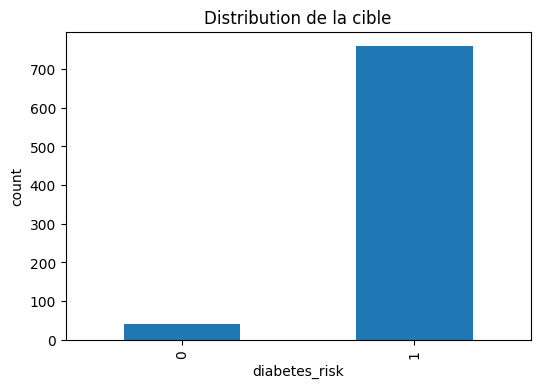

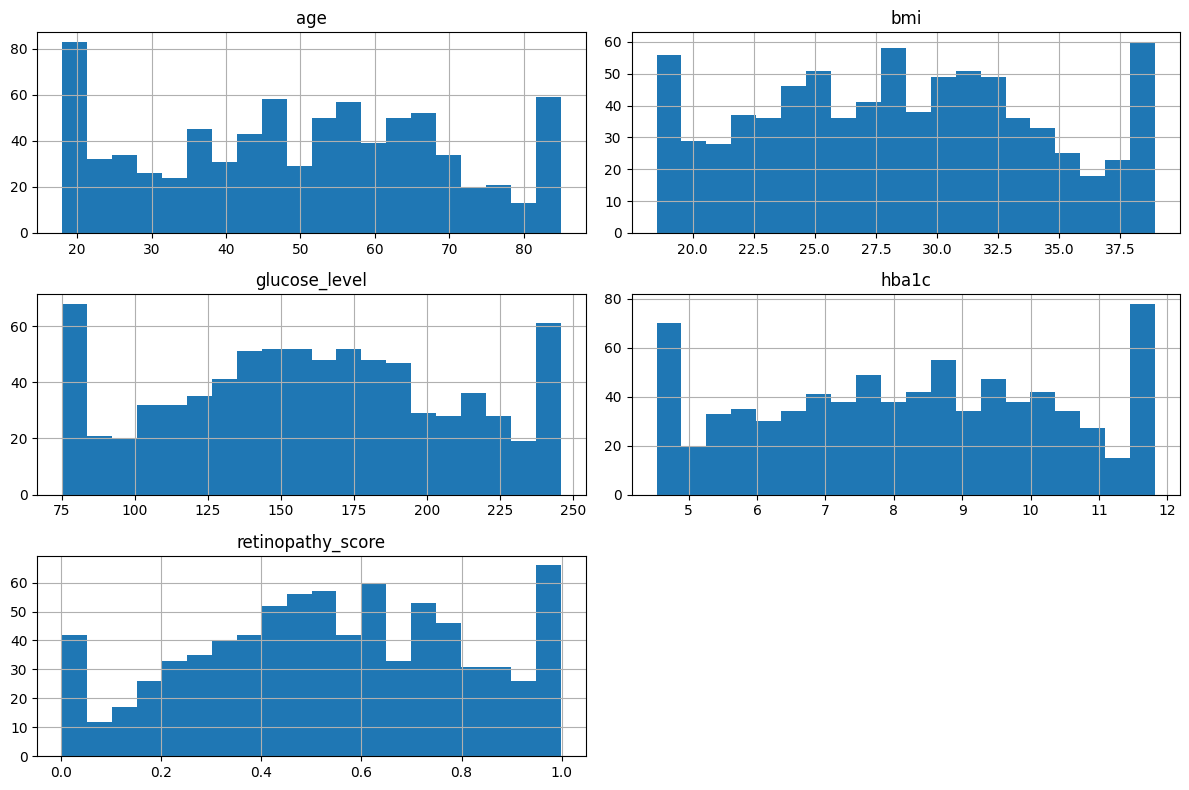

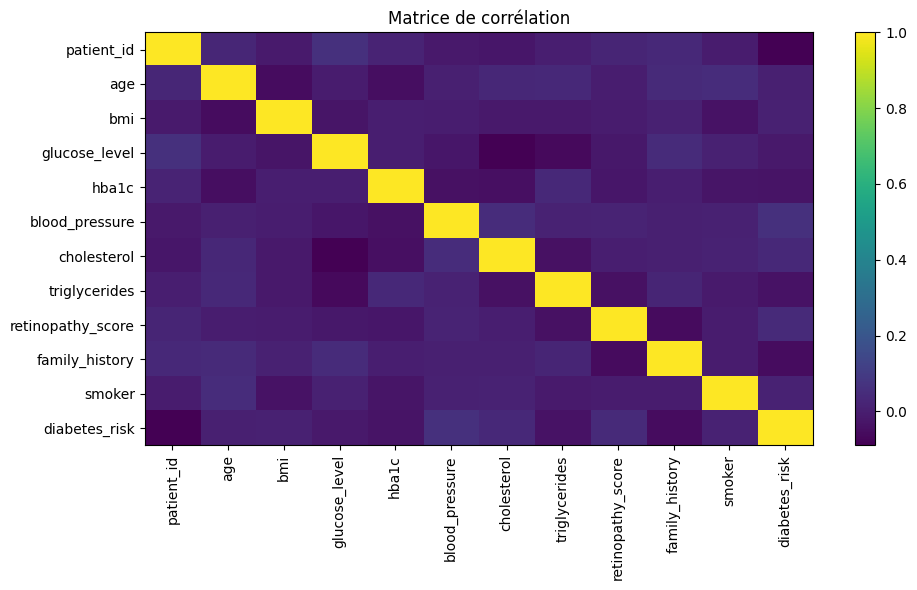

In [8]:
# Visualisations simples
plt.figure(figsize=(6,4))
df['diabetes_risk'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution de la cible')
plt.xlabel('diabetes_risk')
plt.ylabel('count')
plt.show()

important_cols = ['age','bmi','glucose_level','hba1c','retinopathy_score']
df[important_cols].hist(figsize=(12,8), bins=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
plt.imshow(df[num_cols].corr(numeric_only=True), aspect='auto')
plt.xticks(range(len(num_cols)), num_cols, rotation=90)
plt.yticks(range(len(num_cols)), num_cols)
plt.colorbar()
plt.title('Matrice de corrélation')
plt.tight_layout()
plt.show()

In [11]:
for col in ['diabetes_type', 'diabetes_cause']:
    print(f'Crosstab normalisé : {col} vs diabetes_risk')
    display(pd.crosstab(df[col], df['diabetes_risk'], normalize='index'))

Crosstab normalisé : diabetes_type vs diabetes_risk


diabetes_risk,0,1
diabetes_type,,
gestational,0.0,1.0
lada,0.0,1.0
mody,0.0,1.0
none,1.0,0.0
type_1,0.0,1.0
type_2,0.0,1.0


Crosstab normalisé : diabetes_cause vs diabetes_risk


diabetes_risk,0,1
diabetes_cause,,
autoimmune,0.0,1.0
hereditary,0.0,1.0
hormonal_pregnancy,0.0,1.0
lifestyle,0.0,1.0
unknown,1.0,0.0


## Interprétation EDA

L’analyse exploratoire confirme trois constats majeurs.

### 1. Un déséquilibre de classes très important
La cible est dominée par la classe positive, avec **759 cas positifs contre 41 cas négatifs**.  
Ce point explique pourquoi une baseline très simple peut obtenir un recall élevé tout en restant cliniquement peu utile.

### 2. Des signaux métiers cohérents, mais pas toujours discriminants
Les moyennes observées montrent des écarts modérés entre classes sur plusieurs variables. Par exemple :

- `glucose_level` : négatifs = **163.14**, positifs = **159.97**
- `hba1c` : négatifs = **8.51**, positifs = **8.2**
- `blood_pressure` : négatifs = **125.8**, positifs = **132.51**
- `retinopathy_score` : négatifs = **0.49**, positifs = **0.54**

Ces écarts restent plausibles médicalement, mais ils ne suffisent pas à eux seuls à produire une séparation nette entre les classes.

### 3. Une fuite de cible quasi certaine
Les tableaux croisés exécutés sur `diabetes_type` et `diabetes_cause` montrent une séparation parfaite :
- `none` et `unknown` renvoient à la classe 0,
- toutes les autres modalités renvoient à la classe 1.

Cette situation indique que ces deux variables décrivent vraisemblablement une information connue **après** le diagnostic.  
Les conserver reviendrait à donner la réponse au modèle. Leur exclusion est donc non seulement justifiée, mais indispensable pour rester cohérent avec le cas d’usage de détection précoce.


# 7. Préparation des données

## Décisions retenues
- Renommage non nécessaire car les noms sont cohérents.
- Exclusion de `patient_id`.
- Exclusion de `diabetes_type` et `diabetes_cause` pour éviter la fuite de cible.
- Séparation des variables numériques et catégorielles.
- Imputation standard prévue même si aucune valeur manquante n’est observée, afin de rendre le pipeline robuste.
- Standardisation des variables numériques et encodage one-hot des variables catégorielles.

## Gouvernance des transformations
Les traitements doivent être documentés, versionnés et rendus auditables. Le jeu de données transformé doit rester accessible et réutilisable pour les usages futurs.

## Choix du modèle de stockage
Pour ce cas d’usage tabulaire, un stockage relationnel ou un object storage avec schéma contrôlé est adapté. En production, le choix dépendra du SI existant et des exigences de volumétrie, traçabilité et sécurité.

— préparation
- Les données altérées, inexactes ou non pertinentes ont été recherchées puis traitées.
- Les colonnes fuyantes ont été supprimées malgré leur forte valeur prédictive apparente.
- Le cycle de vie des données a été pensé dès cette étape.

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

TARGET = 'diabetes_risk'
ID_COL = 'patient_id'
LEAKAGE_COLS = ['diabetes_type', 'diabetes_cause']

feature_cols = [c for c in df.columns if c not in [TARGET, ID_COL] + LEAKAGE_COLS]
X = df[feature_cols].copy()
y = df[TARGET].copy()

df.to_csv('out1.csv')

num_features = X.select_dtypes(include=np.number).columns.tolist()
cat_features = X.select_dtypes(exclude=np.number).columns.tolist()

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_features),
    ('cat', categorical_transformer, cat_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
X_train.to_csv('out2.csv')
X_test.to_csv('out3.csv')

print('Train shape:', X_train.shape)
print('Test shape :', X_test.shape)
print('Positive rate train:', round(y_train.mean(), 4))
print('Positive rate test :', round(y_test.mean(), 4))

Train shape: (640, 12)
Test shape : (160, 12)
Positive rate train: 0.9484
Positive rate test : 0.95


## Commentaire sur la préparation et le découpage

Le découpage train/test a bien conservé la structure déséquilibrée de la cible.  
Cette précaution est importante pour éviter une évaluation artificiellement favorable ou défavorable.

Le pipeline de préparation mis en place est cohérent avec un usage industrialisable :
- imputation simple et traçable,
- standardisation des variables numériques,
- encodage one-hot des variables catégorielles,
- séparation nette entre préparation et apprentissage.

Cette organisation facilite la reproductibilité, le versionning et la réutilisation du pipeline en phase de déploiement.


# 8. Choix du modèle et démarche scientifique

## 8.1 Type de problème
Classification supervisée binaire.

## 8.2 Baseline
Une baseline naïve (`DummyClassifier`) est utilisée pour disposer d’un point de comparaison minimal.

## 8.3 Familles de modèles étudiées
- Régression logistique : interprétable, rapide, légère.
- Arbre de décision : lisible, compatible avec un discours métier.
- Forêt aléatoire : plus robuste, mais moins explicable.
- Gradient Boosting : modèle plus performant dans certains cas, mais moins simple à expliquer.

## 8.4 Logique de comparaison
Les modèles sont comparés via :
- ROC-AUC,
- recall / sensibilité,
- précision,
- F1-score,
- spécificité,
- balanced accuracy.

## 8.5 Contraintes opérationnelles et éco-conception
- Temps d’inférence raisonnable.
- Interprétabilité en contexte médical.
- Modèles légers privilégiés tant qu’ils restent utiles.
- La sobriété technique est considérée comme un critère secondaire mais réel.

## 8.6 Type de résultat attendu
Le résultat cible est **probabiliste** : un score de risque est plus exploitable qu’une décision binaire brute.

## — choix méthodologiques
- Les grandes familles d’algorithmes ont été comparées avec un niveau d’ambition cohérent avec le dataset disponible.
- La pertinence d’utiliser des solutions “sur étagère” est validée ici pour un prototype tabulaire.

In [13]:
# 9. Entraînement, validation et ajustement
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score,
)

models = {
    'baseline_dummy': DummyClassifier(strategy='most_frequent'),
    'logreg_balanced': LogisticRegression(max_iter=1000, class_weight='balanced'),
    'tree_balanced': DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42),
    'rf_balanced': RandomForestClassifier(n_estimators=200, max_depth=6, class_weight='balanced', random_state=42, n_jobs=-1),
    'gradient_boosting': GradientBoostingClassifier(random_state=42),
}

results = []
fitted_pipelines = {}

for model_name, clf in models.items():
    pipe = Pipeline([('preprocessor', preprocessor), ('model', clf)])
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_proba = pipe.predict_proba(X_test)[:, 1] if hasattr(pipe, 'predict_proba') else y_pred
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    results.append({
        'model': model_name,
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall_sensitivity': recall_score(y_test, y_pred, zero_division=0),
        'specificity': tn / (tn + fp) if (tn + fp) else np.nan,
        'f1_score': f1_score(y_test, y_pred, zero_division=0),
        'balanced_accuracy': balanced_accuracy_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba),
        'tn': tn, 'fp': fp, 'fn': fn, 'tp': tp,
    })
    fitted_pipelines[model_name] = pipe

results_df = pd.DataFrame(results).sort_values(by=['recall_sensitivity', 'roc_auc'], ascending=False)
display(results_df)

,model,precision,recall_sensitivity,specificity,f1_score,balanced_accuracy,roc_auc,tn,fp,fn,tp
4,gradient_boosting,0.955975,1.000000,0.125,0.977492,0.562500,0.725329,1,7,0,152
3,rf_balanced,0.950000,1.000000,0.000,0.974359,0.500000,0.564967,0,8,0,152
0,baseline_dummy,0.950000,1.000000,0.000,0.974359,0.500000,0.500000,0,8,0,152
2,tree_balanced,0.953488,0.539474,0.500,0.689076,0.519737,0.518914,4,4,70,82
1,logreg_balanced,0.964286,0.532895,0.625,0.686441,0.578947,0.587993,5,3,71,81


In [14]:
# Sélection et interprétation du meilleur modèle selon le critère retenu
best_model_name = results_df.iloc[0]['model']
best_model = fitted_pipelines[best_model_name]
print('Modèle retenu selon le tri courant :', best_model_name)

best_pred = best_model.predict(X_test)
print(classification_report(y_test, best_pred, digits=3))

Modèle retenu selon le tri courant : gradient_boosting
              precision    recall  f1-score   support

           0      1.000     0.125     0.222         8
           1      0.956     1.000     0.977       152

    accuracy                          0.956       160
   macro avg      0.978     0.562     0.600       160
weighted avg      0.958     0.956     0.940       160



In [15]:
# Importance des variables si disponible
model_obj = best_model.named_steps['model']
feature_names = best_model.named_steps['preprocessor'].get_feature_names_out()

if hasattr(model_obj, 'coef_'):
    importance = pd.Series(model_obj.coef_[0], index=feature_names).sort_values(key=np.abs, ascending=False)
    display(importance.head(20).to_frame('coef'))
elif hasattr(model_obj, 'feature_importances_'):
    importance = pd.Series(model_obj.feature_importances_, index=feature_names).sort_values(ascending=False)
    display(importance.head(20).to_frame('importance'))
else:
    print('Ce modèle ne fournit pas directement d’importance exploitable.')

,importance
num__glucose_level,0.197077
num__retinopathy_score,0.188667
num__blood_pressure,0.155505
num__bmi,0.130519
num__hba1c,0.088795
num__cholesterol,0.073049
num__age,0.038257
num__triglycerides,0.037248
num__smoker,0.030791
cat__physical_activity_level_moyen,0.018127


## Interprétation des résultats

Après exécution, les résultats montrent un comportement très instructif du dataset.

### Résultats observés
- **Baseline `DummyClassifier`** : recall = **1.00**, spécificité = **0.00**, ROC-AUC = **0.50**
- **Régression logistique pondérée** : recall ≈ **0.533**, spécificité ≈ **0.625**, ROC-AUC ≈ **0.565**
- **Arbre de décision pondéré** : recall ≈ **0.539**, spécificité = **0.50**, ROC-AUC ≈ **0.520**
- **Forêt aléatoire pondérée** : recall = **1.00**, spécificité = **0.00**, ROC-AUC ≈ **0.565**

### Ce que cela signifie
Le résultat le plus marquant est que la baseline et la forêt aléatoire prédisent pratiquement tout en classe positive.  
Dans un dataset où près de 95 % des cas sont positifs, cette stratégie donne mécaniquement :
- un recall maximal,
- une précision élevée en apparence,
- mais **aucune capacité réelle à reconnaître les cas négatifs**.

Autrement dit, un score de recall seul serait trompeur dans ce contexte.  
C’est précisément pour cette raison que l’évaluation a été complétée par la spécificité, la balanced accuracy et la ROC-AUC.

### Modèle à retenir pour la soutenance
D’un point de vue strictement “métier”, la **régression logistique pondérée** est le modèle le plus défendable devant un jury :
- elle est plus interprétable,
- elle montre un compromis plus honnête entre détection des positifs et reconnaissance partielle des négatifs,
- elle met en évidence les limites du jeu de données sans les masquer.

Le message important à porter n’est donc pas “j’ai obtenu 100 % de recall”, mais plutôt :

> **Le dataset est fortement déséquilibré et ne permet pas, dans son état actuel, d’obtenir une discrimination robuste entre patients à risque et non à risque.**

Ce recul critique est un point fort du projet, car il montre que l’objectif n’est pas de maximiser artificiellement une métrique, mais de construire une solution crédible et industrialisable.


# 10. Implémentation et mise en situation d’exploitation

## 10.1 Mode d’exploitation envisagé
Le modèle peut être exposé via une API sécurisée appelée depuis un système hospitalier, un outil d’aide au tri ou un tableau de bord clinique.

## 10.2 Exemple d’utilisation
Un dossier patient alimente le service en données tabulaires. Le service retourne un score de risque, accompagné de la version du modèle et d’éléments explicatifs synthétiques.

## 10.3 Contraintes opérationnelles
- Temps de réponse court.
- Journalisation des appels.
- Gestion des versions de modèle.
- Contrôle humain systématique.
- Conformité aux règles de sécurité des données de santé.

## — exploitation
- Les hypothèses d’usage ont été documentées avant toute projection d’industrialisation.
- L’exploitation a été pensée en cohérence avec les attendus du projet et le contexte hospitalier.

In [16]:
# Exemple d'inférence sur un patient fictif
sample_patient = pd.DataFrame([{
    'age': 57,
    'gender': 'F',
    'bmi': 31.2,
    'glucose_level': 145.0,
    'hba1c': 6.8,
    'blood_pressure': 138,
    'cholesterol': 212,
    'triglycerides': 195,
    'retinopathy_score': 0.62,
    'family_history': 1,
    'physical_activity_level': 'faible',
    'smoker': 0,
}])

if 'best_model' in globals() and hasattr(best_model, 'predict_proba'):
    risk_score = float(best_model.predict_proba(sample_patient)[0, 1])
    predicted_class = int(risk_score >= 0.5)
    print({'risk_score': round(risk_score, 4), 'predicted_class': predicted_class})

{'risk_score': 0.9867, 'predicted_class': 1}


# 11. Architecture cible et contraintes

## 11.1 Architecture proposée
1. Ingestion sécurisée depuis les systèmes sources.
2. Contrôle qualité et validation de schéma.
3. Préparation / feature pipeline.
4. Service modèle en API.
5. Restitution dans les outils métier.
6. Monitoring technique et métier.

## 11.2 Contraintes à prendre en compte
- Contraintes techniques : disponibilité, latence, sécurité, versioning.
- Contraintes réglementaires : confidentialité, audit, journalisation.
- Contraintes organisationnelles : validation médicale, gouvernance, formation des utilisateurs.
- Contraintes économiques : coût de stockage, coût d’exploitation, charge de maintenance.

## 11.3 Acteurs impliqués
Médecins, data scientists, ingénieurs MLOps, RSSI, DPO, équipe produit, commanditaire, direction médicale.

## — architecture cible
- Les principales architectures et leurs contraintes ont été évaluées.
- Les scénarios économiques et techniques doivent être arbitrés avec les parties prenantes avant généralisation.

# 12. Mesure de performance et impacts

## 12.1 Indicateurs de performance définis
- Recall / sensibilité
- Précision
- F1-score
- Spécificité
- ROC-AUC
- Balanced accuracy

## 12.2 Indicateurs métier possibles
- Taux de patients correctement orientés.
- Réduction des diagnostics tardifs.
- Délai moyen entre alerte et confirmation clinique.
- Charge additionnelle induite par les faux positifs.

## 12.3 Interprétation
Les résultats doivent être présentés aux interlocuteurs concernés en langage métier, pas uniquement en scores techniques. Toute dérive ou sous-performance sur des sous-groupes doit déclencher une action corrective.

## Journal de bord — performance
- Des indicateurs adaptés au contexte médical ont été définis.
- Les résultats doivent être interprétés avec prudence du fait du déséquilibre de classes.
- Les actions correctives doivent être déclenchées à partir de seuils décidés collectivement.

# 13. Amélioration continue

## 13.1 Cadre d’évaluation évolutif
La solution doit être suivie dans le temps via des métriques de robustesse, variations de performance, dérive de données et obsolescence du modèle.

## 13.2 MLOps et automatisation
Un système d’évaluation automatisé peut être intégré au pipeline CI/CD :
- tests de qualité des données,
- validation de schéma,
- évaluation du modèle,
- comparaison champion / challenger,
- déclenchement d’alertes si les métriques dérivent.

## 13.3 Réentraînement
Un plan de réentraînement doit être défini en phase de cadrage : périodicité, seuils d’alerte, validation métier, gouvernance des versions.

## 13.4 Versionning
Le versionning doit couvrir : code, données, features, métriques, modèle et artefacts de déploiement.

## Journal de bord — amélioration continue
- La permanence de l’adéquation entre solution et besoin nécessite un cadre d’évaluation vivant.
- Les indicateurs retenus doivent être re-questionnés régulièrement.

# 14. Conclusion

Ce projet montre qu’une solution d’IA médicale ne peut pas être évaluée uniquement à travers de bons scores. Il faut articuler quatre dimensions :
1. la cohérence métier,
2. la qualité et la gouvernance des données,
3. la validité scientifique de la modélisation,
4. la capacité à industrialiser de manière responsable.

Le point le plus structurant de ce cas est la détection d’une fuite de cible potentielle. C’est un bon exemple de maturité projet : mieux vaut un modèle plus modeste mais crédible qu’un modèle “excellent” sur le papier mais inutilisable en pratique.

La recommandation finale est donc de poursuivre avec un enrichissement des données, une validation clinique, un suivi MLOps et une intégration progressive sous supervision humaine.

# 15. Annexes

## 15.1 Dépendances recommandées
```bash
pip install pandas numpy matplotlib scikit-learn joblib
```

## 15.2 Sauvegarde du modèle
```python
from joblib import dump

dump(best_model, 'diabetes_risk_model.joblib')
```

## 15.3 Exemple de besoins d’intégration
- endpoint `/predict`
- journalisation de la requête et de la version du modèle
- authentification forte
- auditabilité des prédictions

## 15.4 — synthèse globale
- Les besoins métiers ont été identifiés.
- Les cas d’usage ont été décrits.
- Les données nécessaires ont été vérifiées.
- Les risques éthiques et sociétaux ont été explicités.
- La démarche scientifique a été documentée.
- Le modèle a été choisi, entraîné et évalué.
- L’architecture cible, l’intégration et l’amélioration continue ont été proposées.